In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os 
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from abc import ABC, abstractmethod
from tqdm import tqdm
import torch
import torch.nn as nn
from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
from datetime import datetime
import yfinance as yf
import traceback
import warnings
from math import floor, ceil
print(torch.cuda.is_available()) 
warnings.filterwarnings('ignore')

False


In [ ]:
def load_column_matrix_yf(
    tickers: list[str], column: str = "Open", start: str = "2010-01-01", end: str = None,) -> tuple[np.ndarray, list[pd.Timestamp]]:
    data = yf.download(tickers, start=start, end=end, auto_adjust=False)

    if len(tickers) == 1:
        df = data[[column]].copy()
        df.columns = tickers
    else:
        df = data[column].copy()

    df = df.dropna()

    matrix = df.values
    dates = df.index.to_list()

    return matrix, dates


tickers = ["SPY", "DIA", "XLE", "XLK", "XLF", "XLB", "XLI"]

p_mat, dates = load_column_matrix_yf(tickers, column="Open", start="2005-01-01")

print(p_mat.shape)
print(dates[:5], dates[-5:])

[*********************100%***********************]  7 of 7 completed

(5342, 7)
[Timestamp('2005-01-03 00:00:00'), Timestamp('2005-01-04 00:00:00'), Timestamp('2005-01-05 00:00:00'), Timestamp('2005-01-06 00:00:00'), Timestamp('2005-01-07 00:00:00')] [Timestamp('2026-03-23 00:00:00'), Timestamp('2026-03-24 00:00:00'), Timestamp('2026-03-25 00:00:00'), Timestamp('2026-03-26 00:00:00'), Timestamp('2026-03-27 00:00:00')]


In [ ]:
class FeatureBuilder:
    def __init__(self, dates, p_mat, seq_len = 30):
        self.p_mat = p_mat.copy()
        self.logged = np.log(p_mat)
        self.features = []
        self.seq_len = seq_len
        self.dates = dates

    def normalize(self, axis = 0):
        self.p_mat /= np.max(self.p_mat, axis = axis)
        self.logged /= np.max(self.logged, axis = axis)

    def z_score(self):
        new_feats = []
        for feat in self.features:
            mean = np.mean(feat, axis = 0)
            std = np.std(feat, axis = 0) + 1e-8
            
            new_feats.append((feat - mean) / std)
        self.features = new_feats

    def add_feature(self, feat):
        self.features.append(feat)

    def build(self):
        min_len = min([f.shape[0] for f in self.features])
        trimmed = [f[-min_len:] for f in self.features]

        return self.dates[-min_len:], np.concatenate(trimmed, axis=1)

    def compile(self):
        dates, m = self.build()
        sequences = []

        for i in range(len(m) - self.seq_len):
            seq = m[i:i+self.seq_len]
            sequences.append(seq)

        sequences = np.array(sequences)

        return dates[self.seq_len:], torch.tensor(sequences, dtype=torch.float32)

# mean = p_mat.mean(axis=0, keepdims=True)
# std = p_mat.std(axis=0, keepdims=True) + 1e-8

# data = (p_mat - mean) / std

builder = FeatureBuilder(dates, p_mat, seq_len=120)

def returns(logged):
    # 1-step log returns
    return np.diff(logged, axis=0)

def abs_returns(logged):
    # 1-step log returns
    return np.abs(np.diff(logged, axis=0))

def multi_horizon_returns(logged, horizons=[10, 25, 50]):
    base = returns(logged)
    features = [base]
    for h in horizons:
        lagged = logged[h:] - logged[:-h]
        features.append(lagged)
    # trim all to the same length
    min_len = min([f.shape[0] for f in features])
    features = [f[-min_len:] for f in features]
    return np.concatenate(features, axis=1)

def rolling_stats(logged, window=20):
    lr = returns(logged)
    mean = np.array([np.mean(lr[i-window:i], axis=0) for i in range(window, len(lr))])
    std = np.array([np.std(lr[i-window:i], axis=0) for i in range(window, len(lr))])
    min_len = min(mean.shape[0], std.shape[0])
    return np.concatenate([mean[-min_len:], std[-min_len:]], axis=1)

def cross_asset_diffs(logged):
    lr = returns(logged)
    n_assets = lr.shape[1]
    diffs = []
    for i in range(n_assets):
        for j in range(i+1, n_assets):
            diffs.append((lr[:, i] - lr[:, j]).reshape(-1, 1))
    return np.concatenate(diffs, axis=1)


#builder.normalize()
builder.add_feature(returns(builder.logged))
builder.add_feature(abs_returns(builder.logged))
builder.add_feature(rolling_stats(builder.logged, int(builder.seq_len / 2)))
builder.add_feature(multi_horizon_returns(builder.logged))
builder.z_score()

_, data = builder.compile()
data.shape

(5342, 7)


torch.Size([5161, 120, 49])

In [21]:
class Autoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size, seq_len, num_layers=1):
        super().__init__()
        self.seq_len = seq_len
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.latent_size = latent_size
        self.num_layers = num_layers

        self.dropout = nn.Dropout(p=0.2)

        # Encoder: compress sequence into latent vector
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc_enc = nn.Linear(hidden_size, latent_size)
        #self.act = nn.LeakyReLU()

        # Decoder: expand latent vector back to sequence
        self.fc_dec_h = nn.Linear(latent_size, num_layers * input_size)
        self.fc_dec_c = nn.Linear(latent_size, num_layers * input_size)
        self.fc_dec = nn.Linear(latent_size, hidden_size)
        self.decoder = nn.LSTM(hidden_size, input_size, num_layers=num_layers, batch_first=True)

    def forward(self, x):
        #try:

        self.dropout(x)
        # ---- Encoder ----
        _, (h, _) = self.encoder(x)                # h: (num_layers, batch, hidden_size)
        h_last = h[-1]   # last layer, backward direction
        h_last = self.dropout(h_last)
        z = self.fc_enc(h_last)

        # h0 = self.fc_dec_h(z)
        # h0 = h0.view(z.size(0), self.num_layers, self.input_size)
        # h0 = h0.permute(1, 0, 2).contiguous()

        # c0 = self.fc_dec_c(z)
        # c0 = c0.view(z.size(0), self.num_layers, self.input_size)
        # c0 = c0.permute(1, 0, 2).contiguous()

        # # ---- Decoder ----
        dec_input = self.fc_dec(z)    # (batch, 1, hidden_size)
        dec_input = self.dropout(dec_input)
        dec_input = dec_input.unsqueeze(1).repeat(1, self.seq_len, 1)  # repeat across sequence length

        # Decoder outputs reconstructed sequence
        out, _ = self.decoder(dec_input)#, (h0, c0))           # (batch, seq_len, input_size)
        return out, z
        # except Exception as e:
        #     traceback.print_exc()

Epoch 1 | Train: 1.0134527602 | Val: 0.7276751489
Epoch 2 | Train: 0.9355453978 | Val: 0.7096373547
Epoch 3 | Train: 0.9129579483 | Val: 0.7101995674
Epoch 4 | Train: 0.9069599840 | Val: 0.6918165900
Epoch 5 | Train: 0.8926637050 | Val: 0.7116014398
Epoch 6 | Train: 0.8755263460 | Val: 0.7103280804
Epoch 7 | Train: 0.8533733573 | Val: 0.7153900898
Epoch 8 | Train: 0.8420449135 | Val: 0.7095611059
Epoch 9 | Train: 0.8429586386 | Val: 0.7019592090
Epoch 10 | Train: 0.8347169614 | Val: 0.6901622758
Epoch 11 | Train: 0.8250320967 | Val: 0.6881541429
Epoch 12 | Train: 0.8217620492 | Val: 0.6884416540
Epoch 13 | Train: 0.8072147367 | Val: 0.6874112144
Epoch 14 | Train: 0.8035055736 | Val: 0.6904129765
Epoch 15 | Train: 0.7968990558 | Val: 0.7128901120
Epoch 16 | Train: 0.7942634373 | Val: 0.6761974602
Epoch 17 | Train: 0.7859999205 | Val: 0.6748696566
Epoch 18 | Train: 0.7776085556 | Val: 0.6710962545
Epoch 19 | Train: 0.7797310632 | Val: 0.6879367576
Epoch 20 | Train: 0.7721696327 | Val: 0.

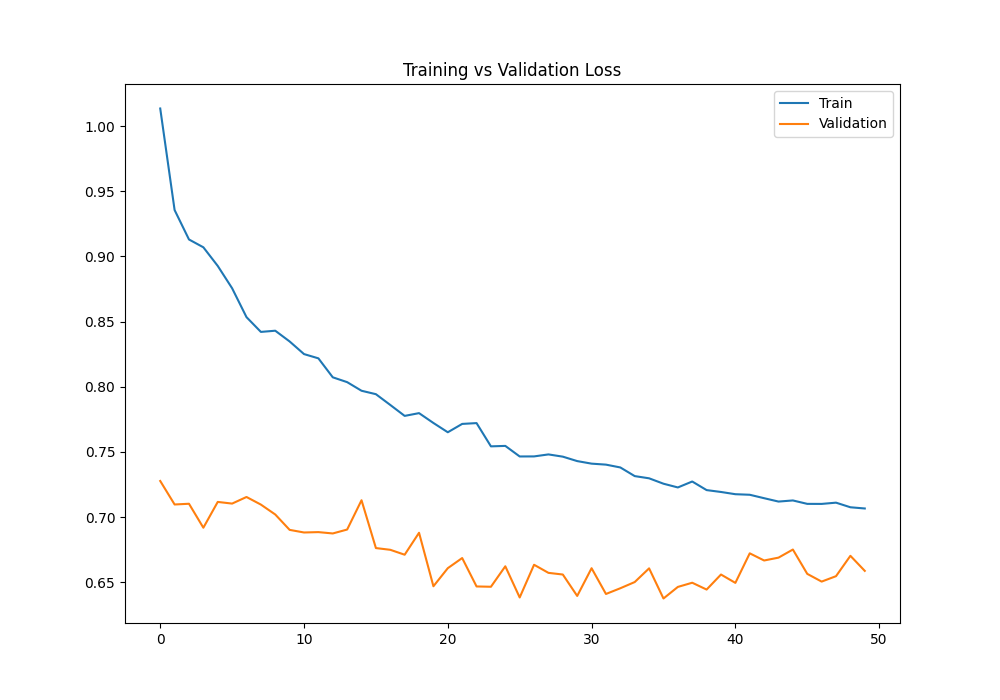

In [22]:
hidden = 64
latent = 16

whereswaldo = Autoencoder(data.shape[2], hidden, latent, data.shape[1], num_layers=3)
optimizer = torch.optim.Adam(whereswaldo.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

loss_fn = nn.MSELoss()

split = int(0.8 * len(data))
train_data = data[:split]
val_data = data[split:]

train_losses = []
val_losses = []

train_dataset = TensorDataset(train_data)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = TensorDataset(val_data)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

for epoch in range(50):

    whereswaldo.train()
    total_train_loss = 0

    for batch in train_loader:
        x = batch[0]   # (batch_size, seq_len, features)
        noise = 0.005 * torch.randn_like(x)
        x_noisy = x + noise

        recon, z = whereswaldo(x_noisy)
        loss = loss_fn(recon, x)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(whereswaldo.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # ===== VALIDATION =====
    whereswaldo.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            x = batch[0]   # (batch_size, seq_len, features)

            recon, z = whereswaldo(x)
            loss = loss_fn(recon, x)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1} | Train: {avg_train_loss:.10f} | Val: {avg_val_loss:.10f}")

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot()

ax.plot(train_losses, label="Train")
ax.plot(val_losses, label="Validation")
ax.legend()
ax.set_title("Training vs Validation Loss")
plt.show()

#summary(whereswaldo, input_size=(32, hidden, latent))

cpu


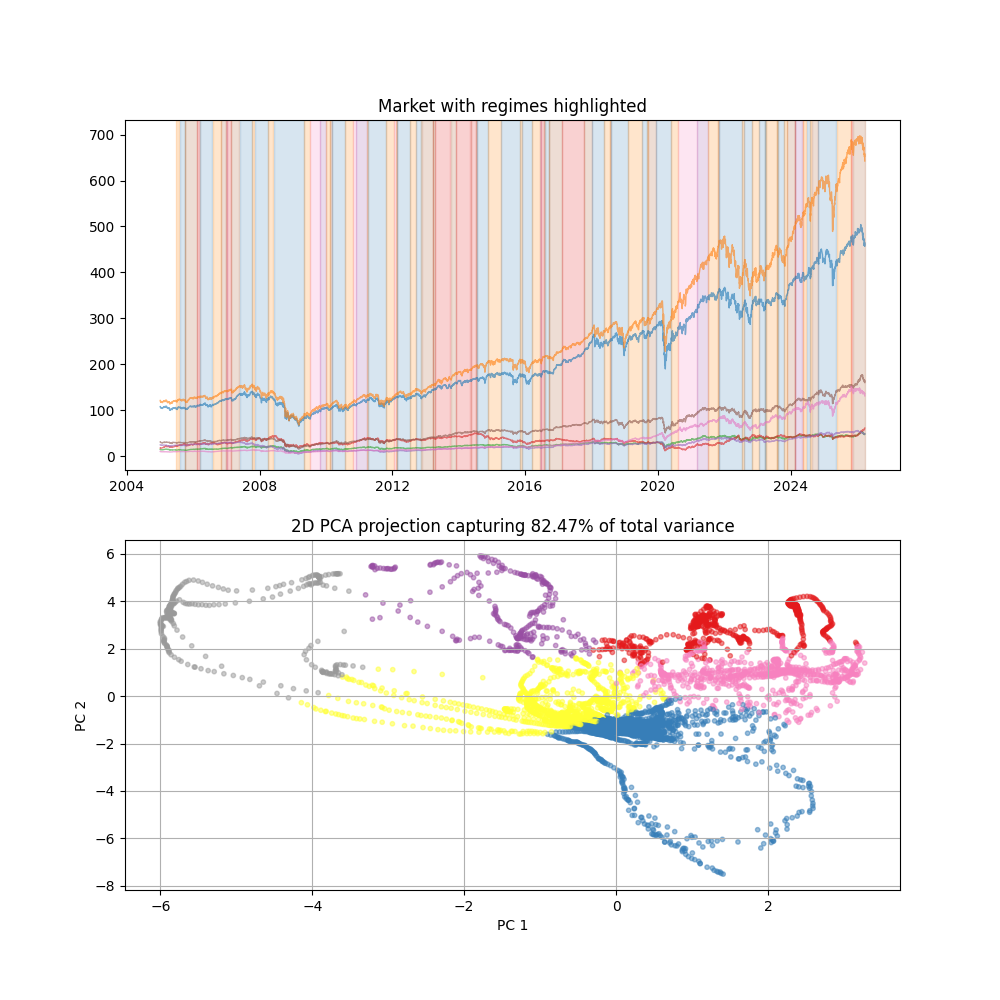

In [25]:
%matplotlib widget

clusters = 6

device = next(whereswaldo.parameters()).device
print(device)

whereswaldo.eval()

with torch.no_grad():
    data_device = data.to(device)   # move input to GPU
    _, z = whereswaldo(data_device)

z = z.cpu().numpy()  # move latent vectors back to CPU for clustering / plotting

z_mean = np.mean(z, axis=0)
z_demean = z - z_mean

cor = np.corrcoef(z_demean, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cor)

z_pca = z_demean @ eigenvectors[:, -2:]

kmeans = KMeans(n_clusters=clusters, random_state=346)
labels = kmeans.fit_predict(z_demean)

time_len = p_mat.shape[0]
regimes = np.full(time_len, np.nan)

for i, label in enumerate(labels):
    regimes[i + builder.seq_len - 1] = label

# forward fill NaNs
for i in range(1, len(regimes)):
    if np.isnan(regimes[i]):
        regimes[i] = regimes[i-1]

regions = []
start = 0

for i in range(1, len(regimes)):
    if regimes[i] != regimes[i-1]:
        regions.append((start, i-1, regimes[i-1]))
        start = i

regions.append((start, len(regimes)-1, regimes[-1]))

fig, (ax_market, ax_pca) = plt.subplots(2, 1, figsize=(10,10))

# plot all assets
for i in range(p_mat.shape[1]):
    ax_market.plot(dates, p_mat[:, i], alpha=0.6, linewidth=1, label = tickers[i])

# color map for regimes
colors = plt.cm.Set1(np.linspace(0, 1, len(np.unique(regimes))))

# draw vertical regions
for (start, end, regime) in regions:
    if np.isnan(regime):
        continue
    ax_market.axvspan(dates[start], dates[end], color=colors[int(regime)], alpha=0.2)

ax_market.set_title("Market with regimes highlighted")

ax_pca.scatter(z_pca[:,0], z_pca[:,1], c=labels, cmap="Set1", alpha = 0.5, s=10)
ax_pca.set_xlabel("PC 1")
ax_pca.set_ylabel("PC 2")
#ax.set_zlabel("PC 3")
ax_pca.set_title(f"2D PCA projection capturing {(np.sum(eigenvalues[-2:]) / latent) * 100:,.2f}% of total variance")
ax_pca.grid(True)
plt.show()

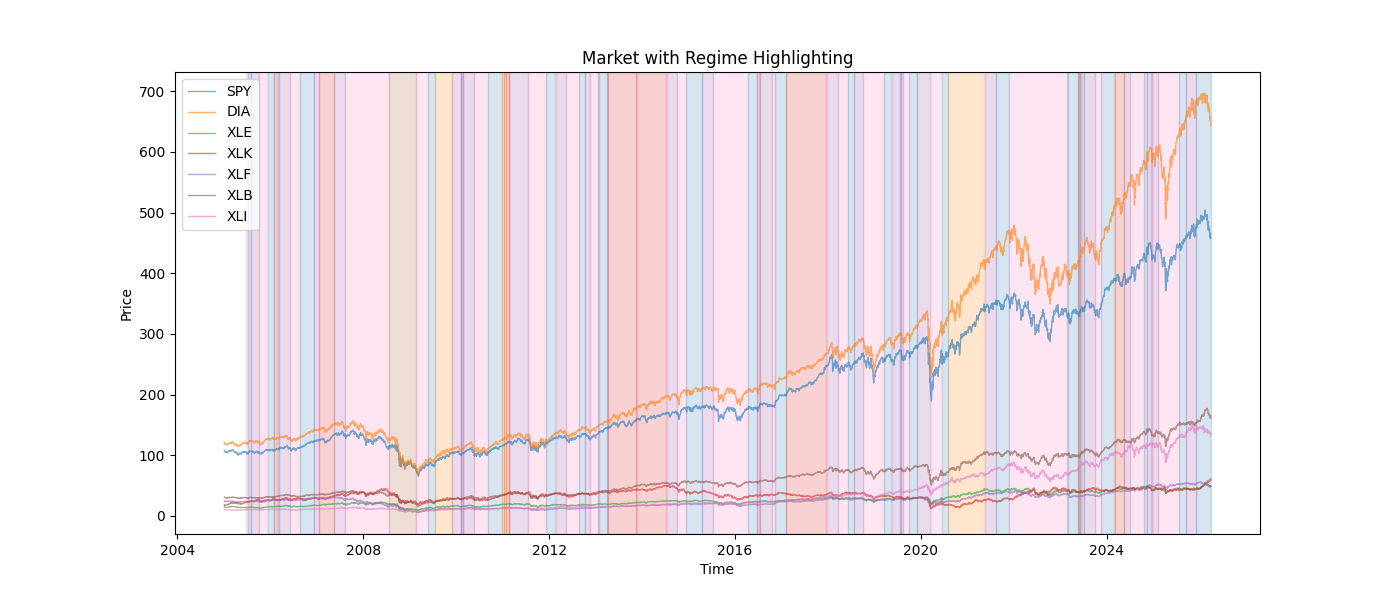

2005-01-03 00:00:00


In [13]:
time_len = p_mat.shape[0]
regimes = np.full(time_len, np.nan)

for i, label in enumerate(labels):
    regimes[i + builder.seq_len - 1] = label

# forward fill NaNs
for i in range(1, len(regimes)):
    if np.isnan(regimes[i]):
        regimes[i] = regimes[i-1]

regions = []
start = 0

for i in range(1, len(regimes)):
    if regimes[i] != regimes[i-1]:
        regions.append((start, i-1, regimes[i-1]))
        start = i

regions.append((start, len(regimes)-1, regimes[-1]))

plt.figure(figsize=(14,6))

# plot all assets
for i in range(p_mat.shape[1]):
    plt.plot(dates, p_mat[:, i], alpha=0.6, linewidth=1, label = tickers[i])

# color map for regimes
colors = plt.cm.Set1(np.linspace(0, 1, len(np.unique(regimes))))

# draw vertical regions
for (start, end, regime) in regions:
    if np.isnan(regime):
        continue
    plt.axvspan(dates[start], dates[end], color=colors[int(regime)], alpha=0.2)

plt.title("Market with Regime Highlighting")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()
print(dates[0])

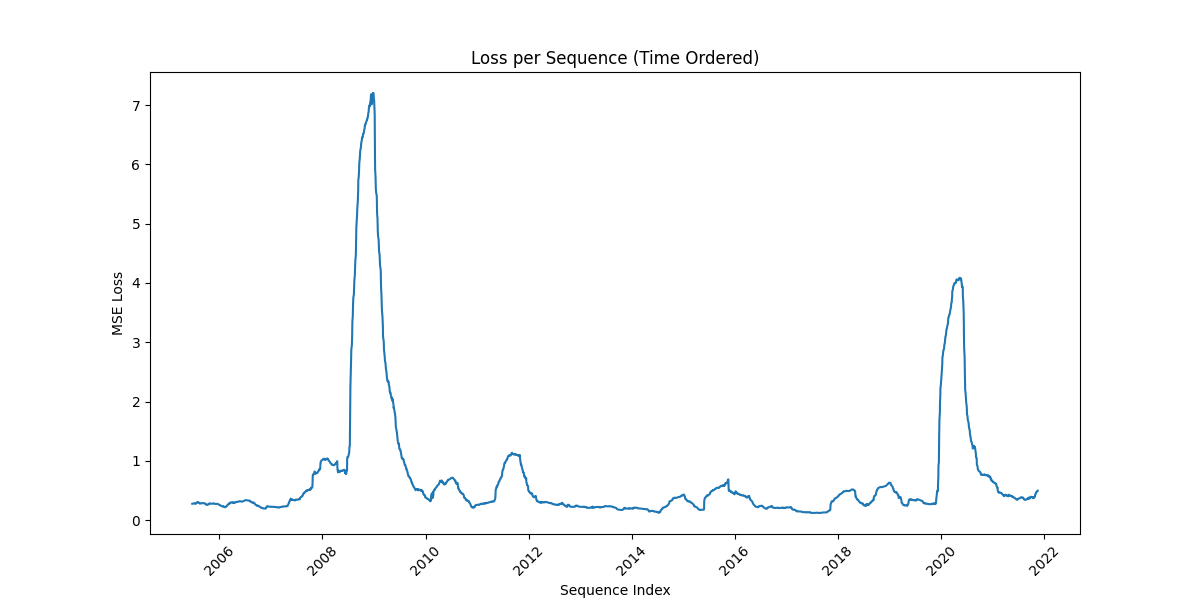

In [14]:
eval_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

loss_fn = nn.MSELoss(reduction='none')

whereswaldo.eval()
seq_losses = []

with torch.no_grad():
    for batch in eval_loader:
        x = batch[0]   # (batch, seq, features)
        recon, _ = whereswaldo(x)

        # (batch, seq, features)
        loss = loss_fn(recon, x)

        # collapse EACH sequence → ONE number
        loss_per_seq = loss.mean(dim=(1, 2))   # (batch,)

        seq_losses.extend(loss_per_seq.cpu().numpy())


seq_dates = dates[builder.seq_len:]

plt.figure(figsize=(12,6))
plt.plot(seq_dates[:len(seq_losses)], seq_losses)
plt.xticks(rotation=45)
plt.title("Loss per Sequence (Time Ordered)")
plt.xlabel("Sequence Index")
plt.ylabel("MSE Loss")
plt.show()

(5281, 49)
5161


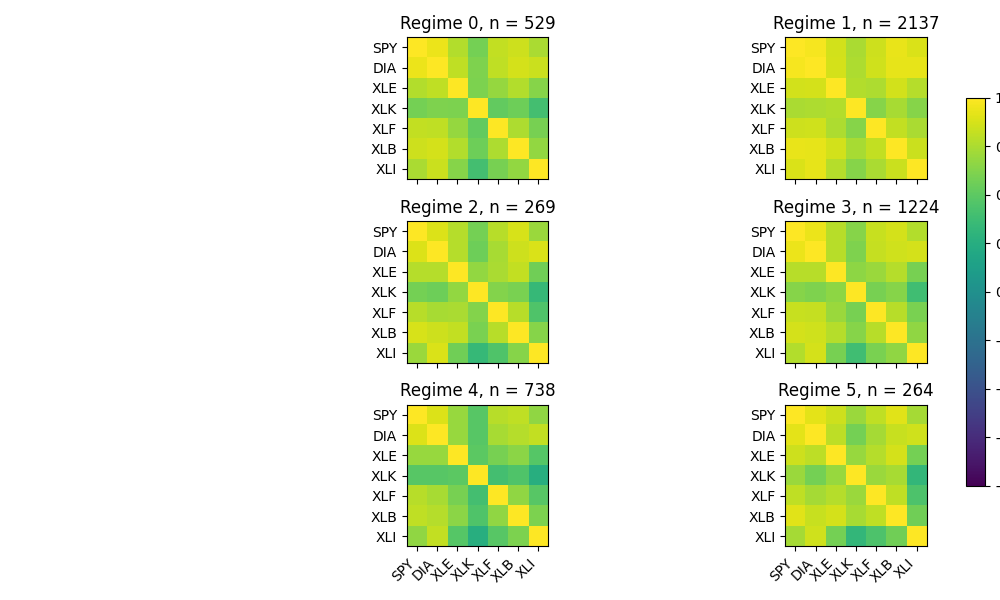

In [27]:
print(builder.build()[1].shape)
print(len(labels))

log_returns = returns(builder.logged)
#features = builder.build()[1]
regime_returns = {}
for label in list(set(labels)):
    regime_returns[label] = []

for i in range(len(labels)):
    regime_returns[labels[i]].append(i)

new_reg_returns = {}
for r, vals in regime_returns.items():
    regime_returns[r] = np.array(regime_returns[r])
    new_reg_returns[r] = log_returns[regime_returns[r]+builder.seq_len]

regime_returns = new_reg_returns

fig, ax = plt.subplots((ceil(clusters/2 -0.25)), 2, figsize=(10,(ceil(clusters/2 -0.25)) * 2), sharex = True)#, sharey = True) 
ax = ax.flatten()

for r, vals in regime_returns.items():
    # vals = np.array(vals)  # if it's a list
    mean = np.mean(vals)
    std = np.std(vals)
    ax[r].set_title(f"Regime {r}, n = {vals.shape[0]}")#, mean = {mean:.3f}, std = {std:.3f}")
    corr = np.corrcoef(vals.T)
    im = ax[r].imshow(corr, vmin=-1, vmax=1)
    ax[r].set_xticks(range(len(tickers)))
    ax[r].set_yticks(range(len(tickers)))
    ax[r].set_xticklabels(tickers, rotation=45, ha='right')
    ax[r].set_yticklabels(tickers)
    # for i in range(vals.shape[1]):
    #     ax[r].hist(vals[:, i], bins=100, histtype='step', linewidth=1, alpha=0.5)#, histtype='step', linewidth=1, density=True, label=f"Regime {r}, mean = {mean:.3f}, std = {std:.3f}")

# plt.legend()
# plt.title("Return Distribution by Regime")
fig.tight_layout()
fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
plt.show()